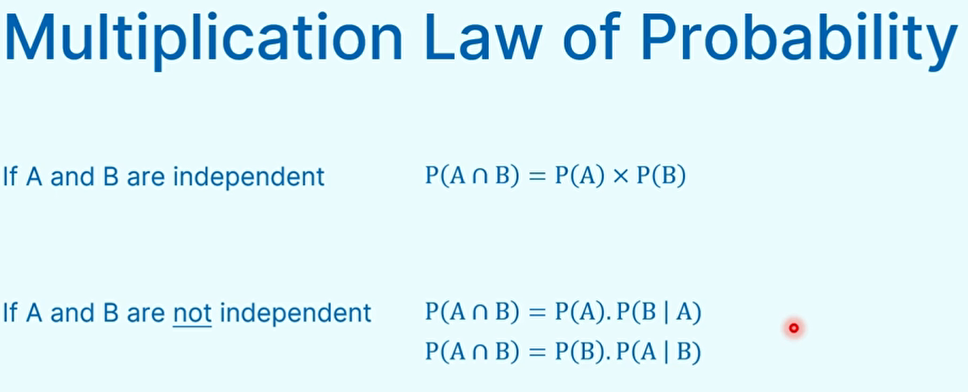
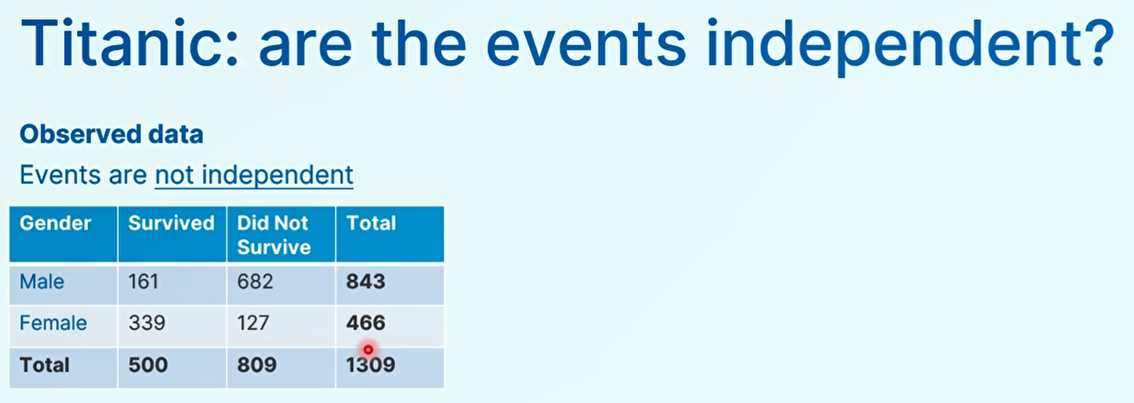
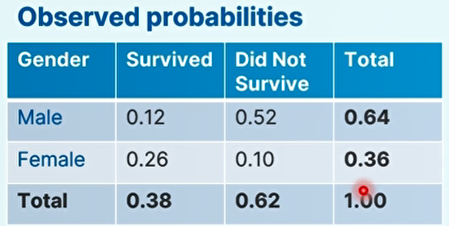

## Full not independent and independent
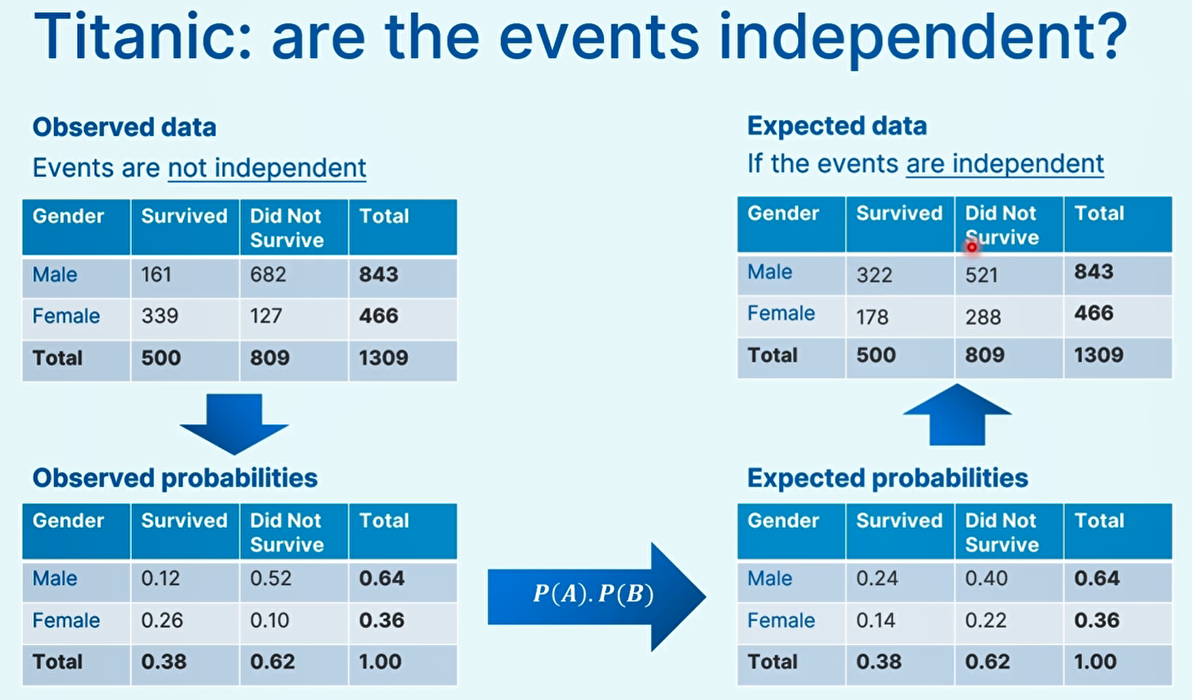

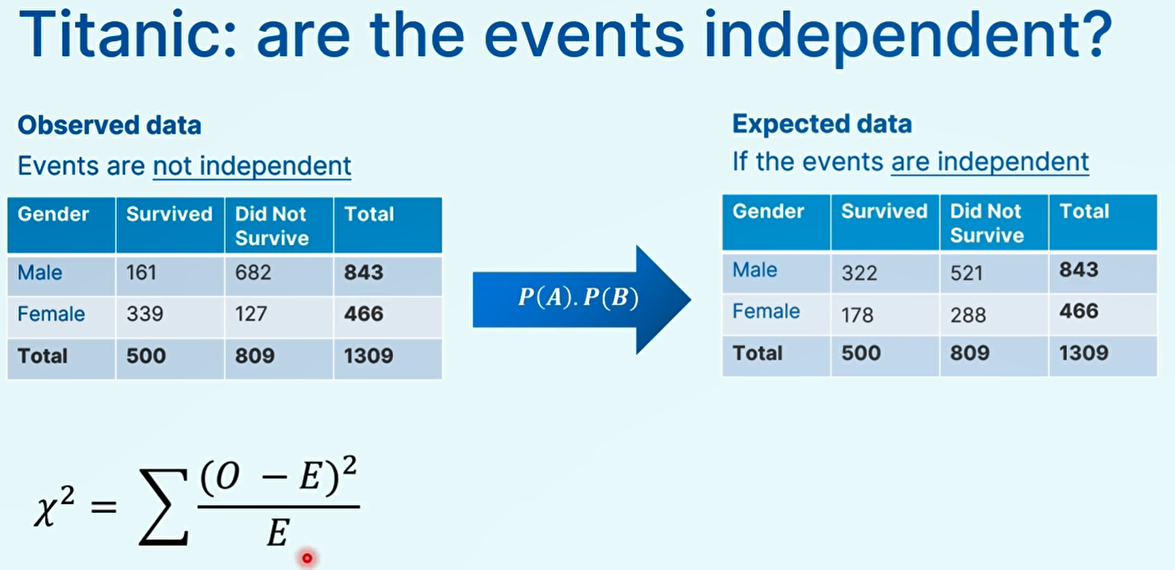

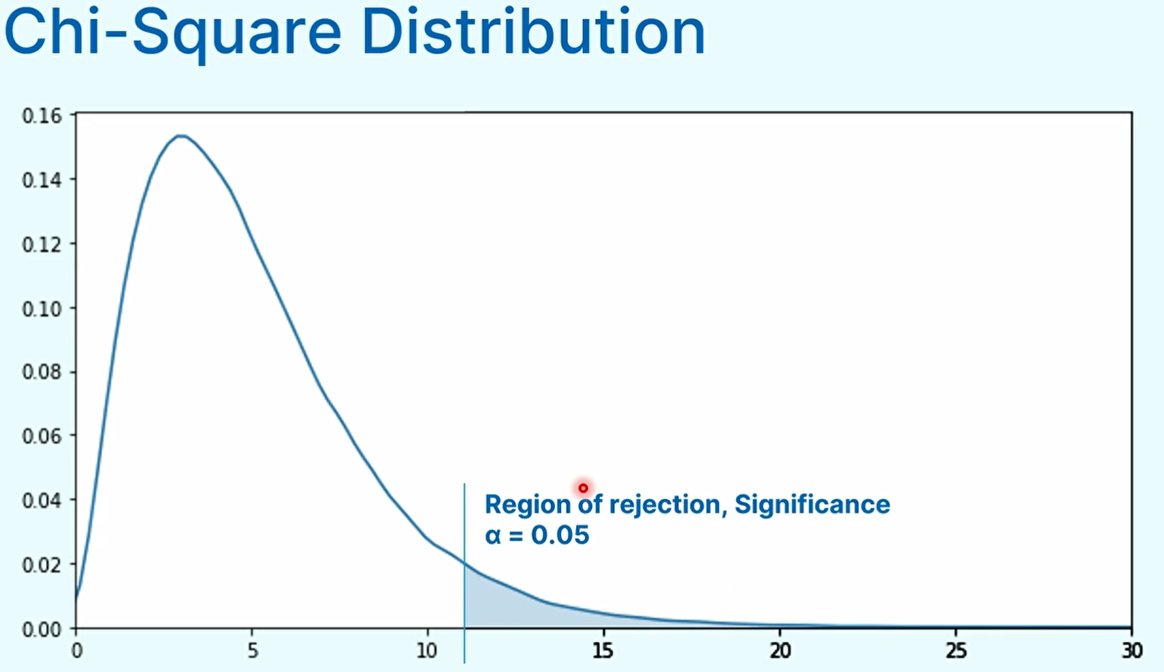

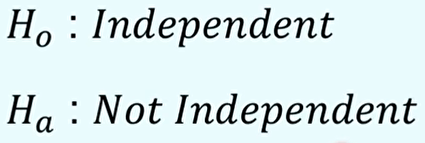

In [ ]:
# so if chi square falls to shared region and less than 0.05 then reject Null hypothesis
# if bigger than 0.05 then Reject alternative hypothesis

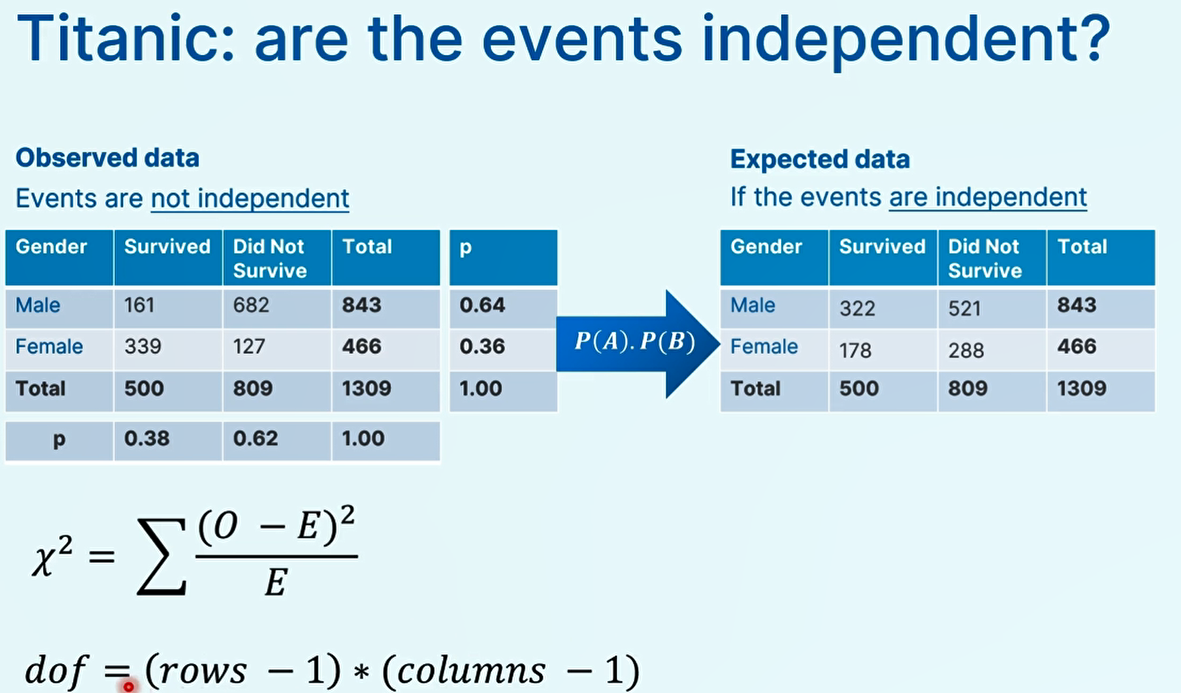

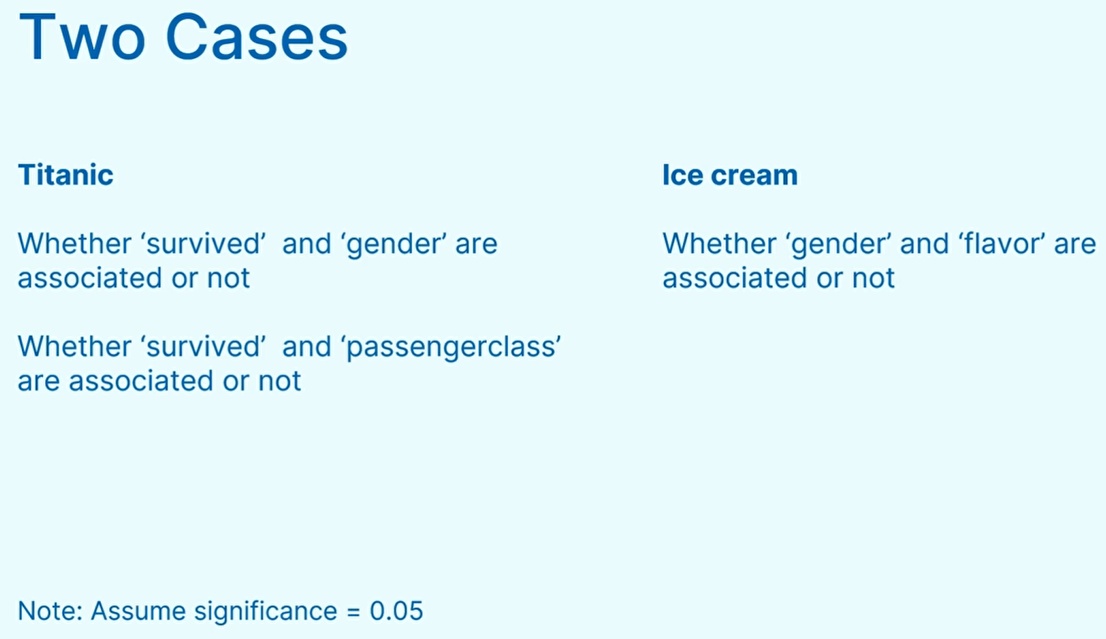

In [2]:
import pandas as pd 
from scipy.stats import chi2_contingency

In [14]:
df = pd.read_csv('../data_analysis/sources/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [16]:
import numpy as np
df['survived_label'] = np.where(df.Survived == 0, 'No', "Yes")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,survived_label
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,No
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Yes
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Yes
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Yes
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,No


In [ ]:
pd.crosstab(df.Sex, df.survived_label) # in crosstab there is no multiple tables

survived_label,No,Yes
Sex,,
female,81,233
male,468,109


In [25]:
df_pivot = pd.pivot_table(data=df, index='Sex', columns='survived_label', values='Name', aggfunc='count')
df_pivot

survived_label,No,Yes
Sex,,
female,81,233
male,468,109


In [ ]:
stats, pvalue, dof, ef = chi2_contingency(df_pivot)
pvalue

# Reject Null Hypothesis, because pvalue < 0.05
# Variable are associated. Sex and survived_lable are associated

np.float64(1.1973570627755645e-58)

In [31]:
df_pivot_pclass = pd.pivot_table(
    data=df, index="Sex", columns=["survived_label", 'Pclass'], values="Name", aggfunc="count"
)
df_pivot_pclass


survived_label  No          Yes        
Pclass           1   2    3   1   2   3
Sex                                    
female           3   6   72  91  70  72
male            77  91  300  45  17  47

In [36]:
stats, pvalue, dof, ef = chi2_contingency(df_pivot_pclass)
pvalue

# Reject Null Hypothesis, because pvalue < 0.05
# Variables are associated

np.float64(5.026114998184125e-59)

In [44]:
df_sibsp = pd.pivot_table(
    data=df, index="Sex", columns="SibSp", values="Name", aggfunc="count"
)
df_sibsp

SibSp,0,1,2,3,4,5,8
Sex,,,,,,,
female,174,106,13,11,6,1,3
male,434,103,15,5,12,4,4


In [46]:
stats, pvalue, dof, ef = chi2_contingency(df_sibsp)
pvalue

# Reject Null Hypothesis
# Variables are associated

np.float64(8.310305033116616e-08)

In [50]:
name_survive = pd.crosstab(df.Name, df.survived_label)

In [54]:
stats, pvalue, dof, ef = chi2_contingency(name_survive)
pvalue

# Not enough proof to reject NUll 
# Variable are not associated. Name and survived are independent

np.float64(0.484248151973633)